# Section I

In [39]:
#Imports
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [40]:
#Getting column names
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

In [41]:
#Making training data
train_url = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain+.txt"
df = pd.read_csv(train_url, names=columns)

print("Shape:", df.shape)

Shape: (125973, 43)


In [42]:
# --- 2. Binarize label: normal vs attack ---
df['binary_label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)
print("Attack rate:", df['binary_label'].mean())

Attack rate: 0.4654171925730117


In [43]:
# --- 3. Split features/target, encode categoricals ---
X = df.drop(columns=['label', 'binary_label', 'difficulty'])
y = df['binary_label']
for col in ['protocol_type', 'service', 'flag']:
    X[col] = LabelEncoder().fit_transform(X[col])

In [44]:
# --- 4. Fit Isolation Forest (unsupervised — never sees y) ---
iso = IsolationForest(
    n_estimators=100,
    max_samples=256,
    contamination=y.mean(),
    random_state=42
)
iso.fit(X)

IsolationForest(contamination=np.float64(0.4654171925730117), max_samples=256,
                random_state=42)

In [45]:
# --- 5. Predict and evaluate against true labels ---
raw_preds = iso.predict(X)                       # 1 = normal, -1 = anomaly
preds = [0 if p == 1 else 1 for p in raw_preds]   # convert to 0/1

print("\nAccuracy:", accuracy_score(y, preds))
print("Precision:", precision_score(y, preds))
print("Recall:", recall_score(y, preds))
print("F1:", f1_score(y, preds))
print("\n", classification_report(y, preds))


Accuracy: 0.6048756479563081
Precision: 0.5755198116908592
Recall: 0.5754903632952414
F1: 0.5755050871163342

               precision    recall  f1-score   support

           0       0.63      0.63      0.63     67343
           1       0.58      0.58      0.58     58630

    accuracy                           0.60    125973
   macro avg       0.60      0.60      0.60    125973
weighted avg       0.60      0.60      0.60    125973



# Section II

In [46]:
import numpy as np

X = df.drop(columns=['label', 'binary_label', 'difficulty'])
y = df['binary_label']

for col in ['protocol_type', 'service', 'flag']:
    X[col] = LabelEncoder().fit_transform(X[col])

In [47]:
# drop noisy/high-variance byte-count features that don't discriminate flood attacks
drop_noisy = ['src_bytes', 'dst_bytes', 'duration', 'hot', 'num_compromised',
              'num_root', 'num_file_creations', 'wrong_fragment']
X_curated = X.drop(columns=[c for c in drop_noisy if c in X.columns])

In [48]:
iso_final = IsolationForest(
    n_estimators=300,
    max_samples=8,              # small subsample so dense DoS clusters look sparse locally
    contamination=y.mean(),
    random_state=42
)
iso_final.fit(X_curated)

IsolationForest(contamination=np.float64(0.4654171925730117), max_samples=8,
                n_estimators=300, random_state=42)

In [49]:
raw_preds = iso_final.predict(X_curated)
preds_final = [0 if p == 1 else 1 for p in raw_preds]

print("Accuracy:", accuracy_score(y, preds_final))
print("Precision:", precision_score(y, preds_final))
print("Recall:", recall_score(y, preds_final))
print("F1:", f1_score(y, preds_final))
print(classification_report(y, preds_final))

Accuracy: 0.9211656466068125
Precision: 0.9153149465281687
Recall: 0.9152993348115299
F1: 0.9153071406032799
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     67343
           1       0.92      0.92      0.92     58630

    accuracy                           0.92    125973
   macro avg       0.92      0.92      0.92    125973
weighted avg       0.92      0.92      0.92    125973



# Section III - Recall Biased

F1-optimal threshold: -0.0014, F1=0.9161, Precision=0.9130, Recall=0.9192

Recall-biased threshold: -0.0293, Precision=0.6933, Recall=0.9700


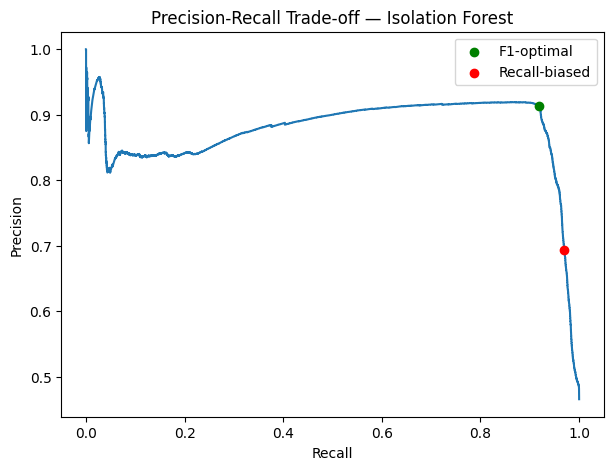

In [50]:
from sklearn.metrics import precision_recall_curve

# decision_function: higher = normal, so flip sign for "higher = more anomalous"
anomaly_scores = -iso_final.decision_function(X_curated)

precisions, recalls, thresholds = precision_recall_curve(y, anomaly_scores)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1s[:-1])
best_threshold = thresholds[best_idx]

print(f"F1-optimal threshold: {best_threshold:.4f}, F1={f1s[best_idx]:.4f}, "
      f"Precision={precisions[best_idx]:.4f}, Recall={recalls[best_idx]:.4f}")

# --- Security-motivated alternative: bias toward recall ---
# In intrusion detection, missing an attack usually costs more than a false alarm,
# so it's worth knowing what you'd sacrifice to push recall near-total.
target_recall = 0.97
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
recall_biased_idx = valid_idx[np.argmax(precisions[valid_idx])]
rb_threshold = thresholds[recall_biased_idx]

print(f"\nRecall-biased threshold: {rb_threshold:.4f}, "
      f"Precision={precisions[recall_biased_idx]:.4f}, Recall={recalls[recall_biased_idx]:.4f}")

# --- Plot ---
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(recalls, precisions)
plt.scatter(recalls[best_idx], precisions[best_idx], color='green', label='F1-optimal', zorder=5)
plt.scatter(recalls[recall_biased_idx], precisions[recall_biased_idx], color='red', label='Recall-biased', zorder=5)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off — Isolation Forest')
plt.legend()
plt.savefig('pr_curve.png')
plt.show()

# Section III - Balanced

In [51]:
# --- Alert-budget threshold: cap false-positive rate on NORMAL traffic ---
n_normal = (y == 0).sum()
budget_fpr = 0.10  # analysts can tolerate at most 10% of normal traffic being flagged

best_budget_idx, best_budget_recall = None, -1
for i, t in enumerate(thresholds):
    preds = (anomaly_scores > t).astype(int)
    fp = ((preds == 1) & (y == 0)).sum()
    fpr = fp / n_normal
    if fpr <= budget_fpr:
        recall = ((preds == 1) & (y == 1)).sum() / (y == 1).sum()
        if recall > best_budget_recall:
            best_budget_recall = recall
            best_budget_idx = i

budget_threshold = thresholds[best_budget_idx]
preds_budget = (anomaly_scores > budget_threshold).astype(int)

print(f"Alert-budget threshold: {budget_threshold:.4f}")
print(f"Precision: {precisions[best_budget_idx]:.3f}  Recall: {best_budget_recall:.3f}")
print(classification_report(y, preds_budget))

Alert-budget threshold: -0.0055
Precision: 0.890  Recall: 0.925
              precision    recall  f1-score   support

           0       0.93      0.90      0.92     67343
           1       0.89      0.93      0.91     58630

    accuracy                           0.91    125973
   macro avg       0.91      0.91      0.91    125973
weighted avg       0.91      0.91      0.91    125973



# Section IV

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_curated, y, test_size=0.2, random_state=42, stratify=y
)

# Isolation Forest — fit on X_train only, never sees y_train
iso = IsolationForest(n_estimators=300, max_samples=8, contamination=y_train.mean(), random_state=42)
iso.fit(X_train)
iso_preds = [0 if p == 1 else 1 for p in iso.predict(X_test)]
print("IF F1:", f1_score(y_test, iso_preds))

# Random Forest — supervised baseline
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("RF F1:", f1_score(y_test, rf_preds))

# --- Zero-day simulation: exclude one attack type entirely from training ---
novel_attack = 'satan'
train_labels = df.loc[X_train.index, 'label']
mask = train_labels != novel_attack
X_train_zd, y_train_zd = X_train[mask.values], y_train[mask.values]

rf_zd = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_zd, y_train_zd)
iso_zd = IsolationForest(n_estimators=300, max_samples=8, contamination=y_train_zd.mean(), random_state=42).fit(X_train_zd)

test_labels = df.loc[X_test.index, 'label']
novel_mask = test_labels == novel_attack
X_test_novel = X_test[novel_mask.values]

print("RF detection rate on unseen attack:", np.mean(rf_zd.predict(X_test_novel)))
print("IF detection rate on unseen attack:", np.mean([0 if p==1 else 1 for p in iso_zd.predict(X_test_novel)]))

IF F1: 0.8670267489711934
RF F1: 0.9962425277540564
RF detection rate on unseen attack: 0.7572178477690289
IF detection rate on unseen attack: 0.9041994750656168
